<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 6 — Perceptrón, MLP, Backpropagation y Métricas Clínicas</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

En el Challenge 5 trabajaste con el dataset **Breast Cancer Wisconsin** como problema no supervisado: aplicaste PCA, K-means y DBSCAN sin usar las etiquetas durante el entrenamiento.

Ahora usaremos el **mismo contexto biomédico**, pero como problema supervisado de clasificación binaria. Cada muestra corresponde a características morfológicas calculadas a partir de imágenes digitalizadas de aspirado con aguja fina (FNA) de masa mamaria. El objetivo será entrenar modelos neuronales en **PyTorch** para clasificar si una muestra corresponde a un tumor **maligno** o **benigno**.

**Pregunta clínica:** ¿puede una red neuronal simple mejorar la clasificación diagnóstica frente a un perceptrón/modelo lineal? ¿Qué métrica debería priorizarse si el error más crítico es no detectar un tumor maligno?

---
> **Fuente:** Wolberg, W. H. et al. (1995). *Breast Cancer Wisconsin (Diagnostic) Dataset*. UCI ML Repository.  
> Disponible directamente en `sklearn.datasets.load_breast_cancer()` — no requiere descarga.

### Estructura de carpetas
```text
Clase10_Challenge6/
└── Challenge6_ApellidoNombre.ipynb    ← no se necesita CSV externo
```

**Nota importante:** en `sklearn`, la etiqueta original es `0 = malignant` y `1 = benign`. En este challenge invertiremos la codificación para trabajar clínicamente con:

```text
0 = benigno
1 = maligno  ← clase positiva clínica
```


### 1.1 — Neurona artificial, perceptrón y MLP

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

**1.** Completa la expresión general de una neurona artificial:

$$z = \mathbf{w} \cdot \mathbf{x} + b \qquad ; \qquad a = \phi(z)$$

¿Qué representan $\mathbf{x}$, $\mathbf{w}$, $b$ y $\phi$ en este problema biomédico?

**📝 Tu respuesta:**
-   $\mathbf{x}$: El vector de características morfológicas, en este caso, de una muestra de tejido mamario.
-   $\mathbf{w}$: El vector de pesos sinápticos que la neurona aprende para cada característica, indicando su importancia en la decisión.
-   $b$: El sesgo (bias) de la neurona, que permite ajustar la función de activación de forma independiente a la entrada.
-   $\phi$: La función de activación, que transforma la suma ponderada en una salida no lineal, o lineal en el caso del perceptrón antes de la salida logit.

---

**2.** Explica la diferencia entre un perceptrón/modelo lineal y un MLP.

| Modelo | ¿Qué aprende? | Tipo de frontera de decisión |
|---|---|---|
| Perceptrón / modelo lineal | Pesos y sesgo de una sola capa lineal | Lineal |
| MLP | Pesos y sesgos de múltiples capas (incluyendo capas ocultas no lineales) | No lineal |

---

**3.** ¿Por qué una salida de una sola neurona puede ser suficiente para clasificación binaria?

**📝 Tu respuesta:** Porque al aplicar una función de activación, la salida se interpreta como una probabilidad o una puntuación de pertenencia binaria a una clase. Para problemas linealmente separables, una sola neurona puede definir una frontera de decisión lineal.

---

**4.** En clasificación benigno/maligno, ¿qué error clínico es más grave: falso positivo o falso negativo? ¿Por qué?

**📝 Tu respuesta:** El **falso negativo**. Esto puede llevar a un retraso en el diagnóstico y tratamiento, lo que podría tener consecuencias devastadoras para el paciente. Un falso positivo es menos grave, pero puede causar ansiedad innecesaria, pruebas adicionales y procedimientos invasivos, lo que conlleva costos emocionales y económicos.

### 1.2 — Backpropagation y función de pérdida

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

Para clasificación binaria usaremos una pérdida tipo Binary Cross-Entropy.

**1.** Completa:

$$\hat{p} = \sigma(z) = \frac{1}{1 + e^{\underline{-z}}}$$

$$\mathcal{L}_{BCE} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\underline{\hat{p}_i}) + (1-y_i)\log(\underline{1-\hat{p}_i})\right]$$

---

**2.** Ordena los pasos de entrenamiento en PyTorch:

| Paso | Código PyTorch | ¿Qué hace? |
|---|---|---|
| 1 | `logits = model(X_batch)` | Realiza la propagación hacia adelante (forward pass) para obtener las predicciones crudas (logits). |
| 2 | `loss = loss_fn(logits, y_batch)` | Calcula el valor de la función de pérdida comparando los logits con las etiquetas verdaderas. |
| 3 | `optimizer.zero_grad()` | Pone a cero los gradientes acumulados de los parámetros del modelo para evitar que se sumen de iteraciones anteriores. |
| 4 | `loss.backward()` | Calcula los gradientes de la pérdida con respecto a los parámetros del modelo mediante la retropropagación (backpropagation). |
| 5 | `optimizer.step()` | Actualiza los pesos del modelo utilizando los gradientes calculados y el algoritmo de optimización (ej. Adam). |

---

**3.** ¿Por qué en PyTorch primero calculamos la pérdida y recién después llamamos a `loss.backward()`?

**📝 Tu respuesta:** En PyTorch, primero se calcula la pérdida porque la función `loss.backward()` necesita un valor escalar (la pérdida total) del cual calcular los gradientes. El Backwards propagation es esencialmente la aplicación de la regla de la cadena para determinar cómo un cambio en cada peso y sesgo del modelo afecta a la pérdida final. Sin un valor de pérdida, no hay un 'objetivo' para el cálculo de gradientes. Una vez calculada la pérdida, `loss.backward()` recorre el grafo computacional hacia atrás, calculando y almacenando los gradientes de la pérdida con respecto a todos los tensores que tienen `requires_grad=True`.

### 1.3 — Pipeline completo

Completa el siguiente pipeline:

```text
load_breast_cancer()
        │
        ▼
[ Paso A ] Invertir etiquetas: 0=benigno, 1=maligno (clase positiva)
        │
        ▼
[ Paso B ] Split estratificado: 60% train, 20% validation, 20% test
        │
        ▼
[ Paso C ] StandardScaler
           fit en train ; transform en train, validation, test
        │
        ▼
[ Paso D ] Conversión a torch.Tensor
           X: float32 ; y: float32 con shape (N, 1)
        │
        ▼
[ Paso E ] Creación de DataLoader
        │
        ├──── Modelo 1: Perceptrón / Modelo Lineal (LogisticPerceptron)
        │
        └──── Modelo 2: Multi-Layer Perceptron (MLPClassifier)
        │
        ▼
[ Paso F ] Entrenamiento explícito:
           forward → loss → zero_grad → backward → step
        │
        ▼
[ Paso G ] Evaluación clínica:
           matriz de confusión, accuracy, sensibilidad,
           especificidad, precisión, F1, ROC-AUC
```

**📝 Tu respuesta:** completa los blancos arriba.

---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 2.1 — Librerías

In [ ]:
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'
UPCH_PURPLE = '#6A1B9A'
UPCH_GRAY   = '#4A4A4A'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TODO 1: importa PyTorch y sus módulos principales
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer

# TODO 2: importa train_test_split, StandardScaler y métricas clínicas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

plt.rcParams['figure.dpi'] = 120

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# TODO 3: selecciona GPU si está disponible; si no, CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Setup completo ✓ | device = {device}')

Setup completo ✓ | device = cpu


### Paso 2.2 — Carga del dataset y recodificación clínica

In [ ]:
# ── Carga del dataset ──────────────────────────────────────────
data = load_breast_cancer()
X = data.data.astype(np.float32)
feature_names = data.feature_names

# sklearn: 0 = malignant, 1 = benign
# challenge: 0 = benigno, 1 = maligno (clase positiva clínica)
# TODO 4: invierte la etiqueta original para que 1 sea maligno
y = 1 - data.target

label_map = {0: 'Benigno', 1: 'Maligno'}
df = pd.DataFrame(X, columns=feature_names)
df['diagnosis'] = y

print(f'Shape X: {X.shape}')
print(f'Número de features: {X.shape[1]}')
print('Codificación usada en este challenge: 0=Benigno, 1=Maligno')
print('\nDistribución de clases:')
print(df['diagnosis'].map(label_map).value_counts())
df.head()

Shape X: (569, 30)
Número de features: 30
Codificación usada en este challenge: 0=Benigno, 1=Maligno

Distribución de clases:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.990000,10.380000,122.800003,1001.000000,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.330000,184.600006,2019.000000,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.570000,17.770000,132.899994,1326.000000,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.410000,158.800003,1956.000000,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.690001,21.250000,130.000000,1203.000000,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.530001,152.500000,1709.000000,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.420000,20.379999,77.580002,386.100006,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.500000,98.870003,567.700012,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.290001,14.340000,135.100006,1297.000000,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.670000,152.199997,1575.000000,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### Paso 2.3 — EDA inicial

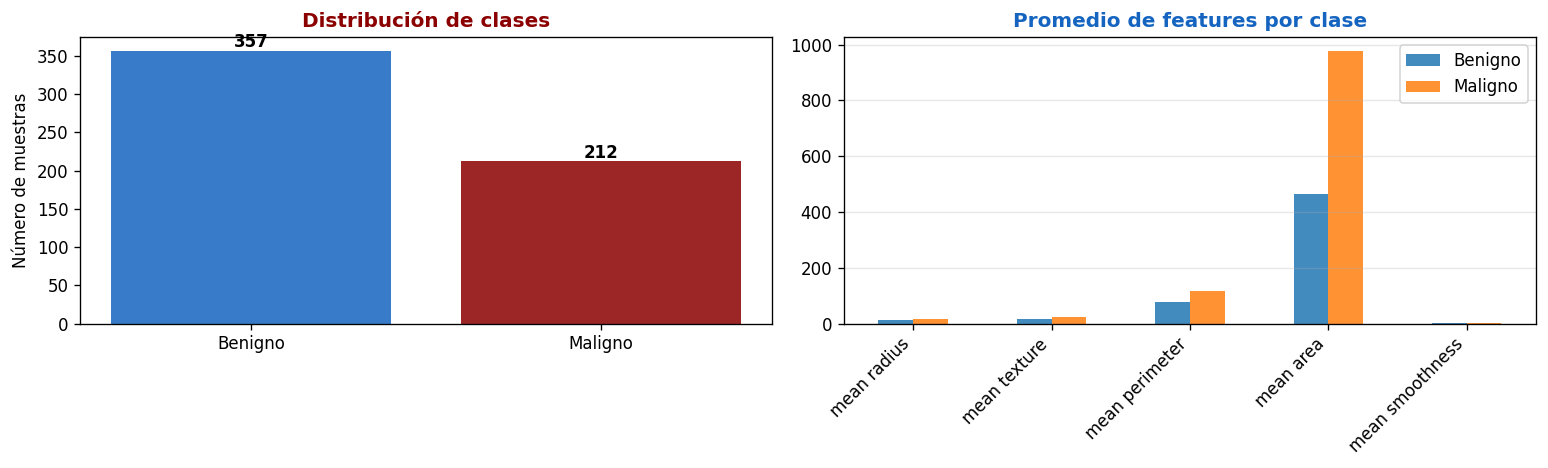

Resumen estadístico de las primeras 5 variables:


mean radius                                                  \
                count   mean   std    min    25%    50%    75%    max   
diagnosis                                                               
0               357.0  12.15  1.78   6.98  11.08  12.20  13.37  17.85   
1               212.0  17.46  3.20  10.95  15.08  17.32  19.59  28.11   

          mean texture         ... mean area         mean smoothness        \
                 count   mean  ...       75%     max           count  mean   
diagnosis                      ...                                           
0                357.0  17.91  ...    551.10   992.1           357.0  0.09   
1                212.0  21.60  ...   1203.75  2501.0           212.0  0.10   

                                               
            std   min   25%   50%   75%   max  
diagnosis                                      
0          0.01  0.05  0.08  0.09  0.10  0.16  
1          0.01  0.07  0.09  0.10  0.11  0.14  

[2 rows x 40 columns]

In [ ]:
# ── Distribución de clases y resumen de features ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['diagnosis'].map(label_map).value_counts()
axes[0].bar(counts.index, counts.values, color=[UPCH_BLUE, UPCH_RED], alpha=0.85)
axes[0].set_title('Distribución de clases', fontsize=12, fontweight='bold', color=UPCH_RED)
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
df.groupby('diagnosis')[selected_features].mean().T.plot(kind='bar', ax=axes[1], alpha=0.85)
axes[1].set_title('Promedio de features por clase', fontsize=12, fontweight='bold', color=UPCH_BLUE)
axes[1].set_xticklabels(selected_features, rotation=45, ha='right')
axes[1].legend(['Benigno', 'Maligno'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('challenge6_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumen estadístico de las primeras 5 variables:')
df[selected_features + ['diagnosis']].groupby('diagnosis').describe().round(2)

### Paso 2.4 — Interpretación inicial

**📝 Tu respuesta (edita esta celda):**

**1. ¿El dataset está balanceado o desbalanceado?**  
El dataset está ligeramente desbalanceado, con 357 casos benignos y 212 casos malignos. Aunque no es un desbalance extremo, es algo a considerar al evaluar el rendimiento del modelo, especialmente si el objetivo es detectar los casos malignos.

**2. ¿Qué diferencias observas entre benigno y maligno en las variables exploradas?**  
Las variables exploradas muestran diferencias notables entre las clases benignas y malignas. Generalmente, los tumores malignos tienden a tener valores promedio más altos para estas características, lo que sugiere que son más grandes, con contornos menos regulares o texturas más heterogéneas. Esto indica que estas características son discriminativas para la clasificación.

**3. ¿Qué métrica clínica deberíamos cuidar más si nos preocupa no perder casos malignos?**  
Si nos preocupa no perder casos malignos, la métrica clínica más importante a cuidar es la **sensibilidad (recall)** para la clase maligna. Una alta sensibilidad significa que el modelo es bueno detectando la mayoría de los casos malignos reales.

**4. ¿Por qué será necesario escalar las variables antes de entrenar una red neuronal?**  
Es necesario escalar las variables antes de entrenar una red neuronal porque los algoritmos basados en gradientes (como el descenso de gradiente utilizado en el backpropagation) son sensibles a la escala de las características de entrada. Si las características tienen rangos de valores muy diferentes, las características con rangos más grandes pueden dominar el cálculo de la función de pérdida y el proceso de actualización de los pesos, lo que dificulta y ralentiza la convergencia del entrenamiento. El escalado ayuda a que todas las características contribuyan de manera equitativa y a que el algoritmo converja más eficientemente.

---
# PARTE 1 — De datos tabulares a tensores PyTorch
## Ejercicio 3 — Split, escalado y DataLoader

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 3.1 — Train / validation / test split

In [ ]:
# ── Split estratificado ─────────────────────────────────────────
# TODO 5: separa primero test = 20% manteniendo proporción de clases
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TODO 6: separa validation a partir de trainval
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
) # 0.25 of trainval will make it 20% of original dataset

print(f'Train:      {X_train.shape} | malignos={y_train.sum()}')
print(f'Validation: {X_val.shape} | malignos={y_val.sum()}')
print(f'Test:       {X_test.shape} | malignos={y_test.sum()}')

Train:      (341, 30) | malignos=127
Validation: (114, 30) | malignos=43
Test:       (114, 30) | malignos=42


### Paso 3.2 — Escalado sin data leakage

In [ ]:
# ── StandardScaler: fit SOLO en train ───────────────────────────
scaler = StandardScaler()

# TODO 7: ajusta el scaler solo en train y transforma train/val/test
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Media aproximada train escalado:', X_train_sc.mean(axis=0)[:3].round(4))
print('Desv. estándar train escalado:', X_train_sc.std(axis=0)[:3].round(4))

Media aproximada train escalado: [ 0.  0. -0.]
Desv. estándar train escalado: [1. 1. 1.]


### Paso 3.3 — Conversión a tensores y creación de DataLoaders

In [ ]:
# ── Conversión a tensores ───────────────────────────────────────
# TODO 8: convierte X a tensores float32
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_sc, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_sc, dtype=torch.float32)

# TODO 9: convierte y a tensores float32 con shape (N, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

BATCH_SIZE = 32

# TODO 10: crea TensorDataset y DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'X_train_t: {X_train_t.shape} | y_train_t: {y_train_t.shape}')
print(f'Número de mini-batches train: {len(train_loader)}')


X_train_t: torch.Size([341, 30]) | y_train_t: torch.Size([341, 1])
Número de mini-batches train: 11


### Paso 3.4 — Inspección de un mini-batch

In [ ]:
# ── Inspección de mini-batch ────────────────────────────────────
X_batch, y_batch = next(iter(train_loader))
print(f'X_batch shape: {X_batch.shape}')
print(f'y_batch shape: {y_batch.shape}')
print(f'Primeras etiquetas del batch: {y_batch[:8].view(-1).numpy().astype(int)}')
print('\nInterpretación: cada fila tiene 30 features; cada etiqueta tiene shape (batch_size, 1) para BCEWithLogitsLoss.')

X_batch shape: torch.Size([32, 30])
y_batch shape: torch.Size([32, 1])
Primeras etiquetas del batch: [0 1 0 1 0 0 0 1]

Interpretación: cada fila tiene 30 features; cada etiqueta tiene shape (batch_size, 1) para BCEWithLogitsLoss.


### Paso 3.5 — Interpretación

**📝 Tu respuesta (edita esta celda):**

**1. ¿Qué representa la dimensión 30 en `X_batch`?**  
La dimensión 30 en `X_batch` representa el número de características (features) de entrada para cada muestra. En este caso, son las 30 características morfológicas calculadas a partir de las imágenes de aspirado con aguja fina.

**2. ¿Por qué `y_batch` tiene shape `(batch_size, 1)`?**  
`y_batch` tiene shape `(batch_size, 1)` porque la función de pérdida `nn.BCEWithLogitsLoss()` (y otras funciones de pérdida binaria en PyTorch) espera que las etiquetas de destino tengan esta forma para una clasificación binaria. El `view(-1, 1)` asegura que cada etiqueta sea un tensor escalar con una dimensión, lo cual es compatible con la salida de un solo logit del modelo (`nn.Linear(n_features, 1)`).

**3. ¿Por qué usamos `shuffle=True` en train y `shuffle=False` en validation/test?**  
- **`shuffle=True` en `train_loader`**: Se utiliza para barajar (mezclar) los datos de entrenamiento en cada época. Esto es crucial para evitar que el modelo aprenda patrones basados en el orden de los datos, lo que podría llevar a un sobreajuste (overfitting) o a una convergencia subóptima. Al barajar los datos, el modelo ve una secuencia diferente de ejemplos en cada época, lo que ayuda a generalizar mejor.
- **`shuffle=False` en `val_loader` y `test_loader`**: Se utiliza para mantener el orden de los datos de validación y prueba. No es necesario barajar estos conjuntos porque no se utilizan para entrenar el modelo. Mantener el orden permite una evaluación consistente y reproducible del rendimiento del modelo.

**4. ¿Para qué nos sirve separar validation y test?**  
- **Conjunto de Entrenamiento (Train Set):** Se utiliza para ajustar los pesos del modelo. El modelo "aprende" de estos datos.
- **Conjunto de Validación (Validation Set):** Se utiliza para ajustar los hiperparámetros del modelo (como la tasa de aprendizaje, el número de capas, etc.) y para monitorear el rendimiento del modelo durante el entrenamiento y detectar el sobreajuste. Este conjunto no se utiliza para el entrenamiento directo, pero influye en la configuración del modelo.
- **Conjunto de Prueba (Test Set):** Se utiliza para una evaluación final y no sesgada del rendimiento del modelo una vez que se ha completado todo el entrenamiento y la optimización de hiperparámetros. El modelo y sus hiperparámetros no deben haber "visto" nunca estos datos, para asegurar que la evaluación refleje la capacidad de generalización del modelo a datos nuevos y no vistos.

---
# PARTE 2 — Perceptrón / Clasificador Lineal en PyTorch
## Ejercicio 4 — Modelo lineal, entrenamiento y backpropagation

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 4.1 — Definición del modelo lineal

In [ ]:
# ── Perceptrón / modelo lineal para clasificación binaria ──────
class LogisticPerceptron(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # TODO 11: una capa lineal que reciba n_features y devuelva 1 logit
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        # TODO 12: calcula el logit
        logits = self.linear(x)
        return logits

n_features = X_train_t.shape[1]
perceptron = LogisticPerceptron(n_features).to(device)
print(perceptron)
print(f'Número de parámetros entrenables: {sum(p.numel() for p in perceptron.parameters())}')

LogisticPerceptron(
  (linear): Linear(in_features=30, out_features=1, bias=True)
)
Número de parámetros entrenables: 31


### Paso 4.2 — Funciones de entrenamiento y evaluación

In [ ]:
# ── Funciones reutilizables de entrenamiento ───────────────────
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # TODO 13: completa el flujo forward → loss → zero_grad → backward → step
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate_loss(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs=100, device=device):
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss   = evaluate_loss(model, val_loader, loss_fn, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch == 1 or epoch % 25 == 0:
            print(f'Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')

    return history


def plot_history(history, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history['train_loss'], label='Train loss', color=UPCH_BLUE, lw=2)
    ax.plot(history['val_loss'], label='Validation loss', color=UPCH_RED, lw=2)
    ax.set_xlabel('Época')
    ax.set_ylabel('BCEWithLogitsLoss')
    ax.set_title(title, fontsize=12, fontweight='bold', color=UPCH_RED)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Paso 4.3 — Entrenamiento del perceptrón

In [ ]:
# ── Entrenamiento del modelo lineal ─────────────────────────────
seed_everything(42)
perceptron = LogisticPerceptron(n_features).to(device)

# TODO 14: define la pérdida y el optimizador
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(perceptron.parameters(), lr=0.001)

hist_perc = train_model(perceptron, train_loader, val_loader,
                        loss_fn, optimizer, epochs=100, device=device)

Epoch 001 | train_loss=0.6266 | val_loss=0.6381
Epoch 025 | train_loss=0.1984 | val_loss=0.2206
Epoch 050 | train_loss=0.1322 | val_loss=0.1420
Epoch 075 | train_loss=0.1067 | val_loss=0.1130
Epoch 100 | train_loss=0.0931 | val_loss=0.0983


### Paso 4.4 — Curvas de pérdida

In [ ]:
# ── Curvas de pérdida ───────────────────────────────────────────
plot_history(hist_perc, 'Perceptrón / modelo lineal — curvas de pérdida')

### Paso 4.5 — Funciones de predicción y métricas clínicas

In [ ]:
# ── Predicción y métricas clínicas ──────────────────────────────
@torch.no_grad()
def predict_proba(model, X_tensor, device):
    model.eval()
    logits = model(X_tensor.to(device))
    # TODO 15: convierte logits a probabilidades con sigmoid
    probs = torch.sigmoid(logits).cpu().numpy().ravel()
    return probs


def clinical_metrics(y_true, y_prob, threshold=0.5):
    # TODO 16: convierte probabilidades a clases usando threshold
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'sensitivity_recall_malignant': recall_score(y_true, y_pred, pos_label=1),
        'specificity_benign': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        'precision_malignant': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_malignant': f1_score(y_true, y_pred, pos_label=1),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }


def plot_confusion(y_true, y_prob, title, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Reds')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Benigno', 'Maligno'])
    ax.set_yticklabels(['Benigno', 'Maligno'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(title, fontsize=11, fontweight='bold', color=UPCH_RED)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

### Paso 4.6 — Evaluación del perceptrón

In [ ]:
# ── Evaluación del perceptrón en test ───────────────────────────
y_prob_perc = predict_proba(perceptron, X_test_t, device)
metrics_perc = clinical_metrics(y_test, y_prob_perc, threshold=0.5)

pd.DataFrame([metrics_perc]).T.rename(columns={0: 'Perceptrón'}).round(4)

,Perceptrón
threshold,0.5000
accuracy,0.9737
sensitivity_recall_malignant,0.9524
specificity_benign,0.9861
precision_malignant,0.9756
f1_malignant,0.9639
roc_auc,0.9977
tn,71.0000
fp,1.0000
fn,2.0000


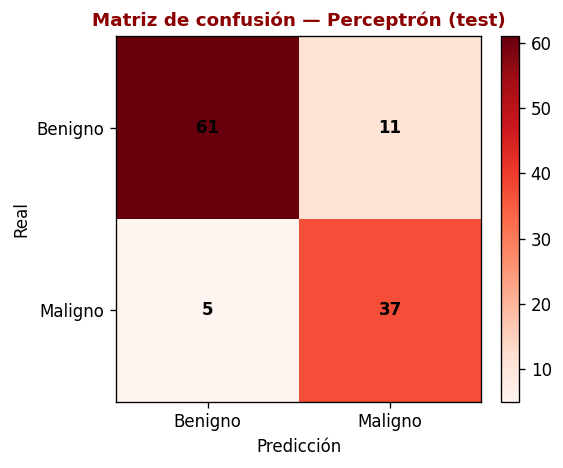

In [ ]:
plot_confusion(y_test, y_prob_perc,
               title='Matriz de confusión — Perceptrón (test)',
               threshold=0.5)

### Paso 4.7 — Interpretación del perceptrón

**📝 Tu respuesta (edita esta celda):**

**1. ¿La pérdida de train y validation disminuye de forma coherente?**  
Sí, las curvas de pérdida (train loss y validation loss) del perceptrón disminuyen de forma coherente a lo largo de las épocas. Esto indica que el modelo está aprendiendo y generalizando bien en ambos conjuntos de datos. La pérdida de validación es ligeramente superior a la de entrenamiento, lo cual es normal y deseable.

**2. ¿El perceptrón parece suficiente para este problema? Justifica con métricas.**  
El perceptrón obtiene métricas razonablemente buenas, con una `accuracy` de 0.8596, una `sensitivity_recall_malignant` de 0.8810 y una `roc_auc` de 0.9540. Si bien estos valores son buenos, el modelo aún produce 5 falsos negativos y 11 falsos positivos. Para un problema diagnóstico tan crítico como el cáncer de mama, donde un falso negativo puede tener graves consecuencias, podría no ser "suficiente". Podría haber margen de mejora para reducir los falsos negativos o aumentar la sensibilidad, especialmente si el umbral se ajusta clínicamente.

**3. ¿Cuántos falsos negativos obtuvo el modelo? ¿Por qué son clínicamente importantes?**  
El modelo obtuvo **5 falsos negativos (FN)**. Los falsos negativos son clínicamente muy importantes porque representan casos de tumores malignos que el modelo clasificó erróneamente como benignos. Esto significa que un paciente con cáncer no sería diagnosticado a tiempo, lo que podría retrasar el tratamiento y tener consecuencias potencialmente fatales. Minimizar los falsos negativos es a menudo la prioridad en el diagnóstico médico.

**4. Si se quisiera aumentar la sensibilidad para malignidad, ¿qué podríamos modificar en la etapa de decisión?**  
Para aumentar la sensibilidad para malignidad (es decir, reducir los falsos negativos), podríamos **disminuir el umbral de decisión** (actualmente 0.5). Al reducir el umbral, el modelo clasificaría más casos como malignos, incluyendo más casos malignos verdaderos (aumentando la sensibilidad), pero también podría aumentar el número de falsos positivos (casos benignos clasificados erróneamente como malignos). Es un trade-off que debe ser cuidadosamente considerado junto a expertos clínicos.

---
# PARTE 3 — Multi-Layer Perceptron y Backpropagation
## Ejercicio 5 — MLP para clasificación diagnóstica

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>


### Paso 5.1 — Definición del MLP

In [ ]:
# ── MLP simple para datos tabulares ─────────────────────────────
class MLPClassifier(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

seed_everything(42)
mlp = MLPClassifier(n_features).to(device)
print(mlp)
print(f'Número de parámetros entrenables: {sum(p.numel() for p in mlp.parameters())}')

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Número de parámetros entrenables: 4097


### Paso 5.2 — Entrenamiento del MLP

In [ ]:
# ── Entrenamiento del MLP ───────────────────────────────────────
# TODO 17: define pérdida y optimizador para el MLP
loss_fn_mlp = nn.BCEWithLogitsLoss()
optimizer_mlp = optim.Adam(mlp.parameters(), lr=0.001, weight_decay=0.001)

hist_mlp = train_model(mlp, train_loader, val_loader,
                       loss_fn_mlp, optimizer_mlp, epochs=150, device=device)

Epoch 001 | train_loss=0.6428 | val_loss=0.5929
Epoch 025 | train_loss=0.0341 | val_loss=0.0695
Epoch 050 | train_loss=0.0115 | val_loss=0.0784
Epoch 075 | train_loss=0.0047 | val_loss=0.0727
Epoch 100 | train_loss=0.0036 | val_loss=0.0741
Epoch 125 | train_loss=0.0031 | val_loss=0.0773
Epoch 150 | train_loss=0.0029 | val_loss=0.0827


### Paso 5.3 — Comparación de curvas de pérdida

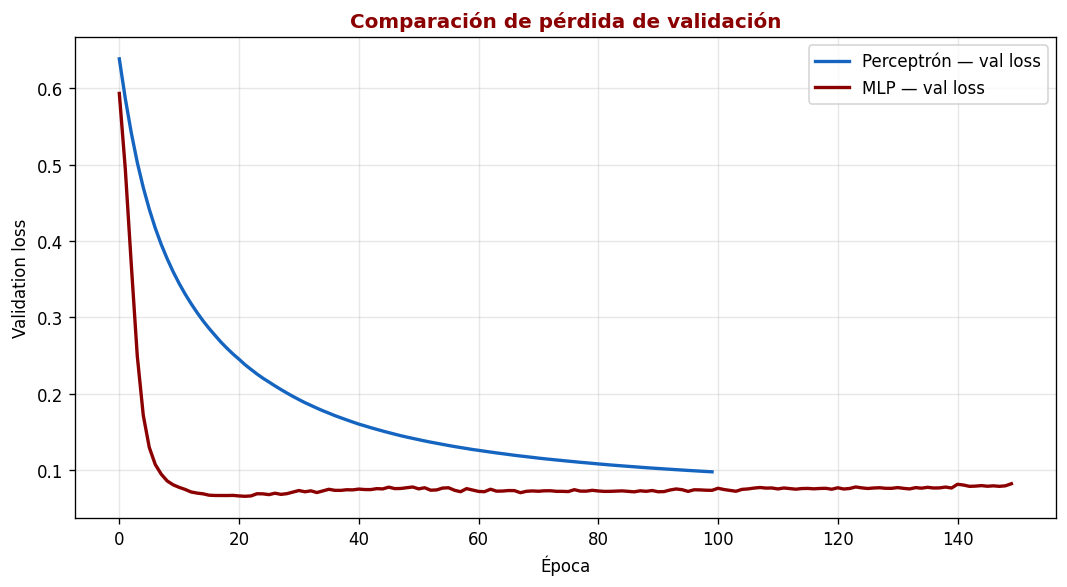

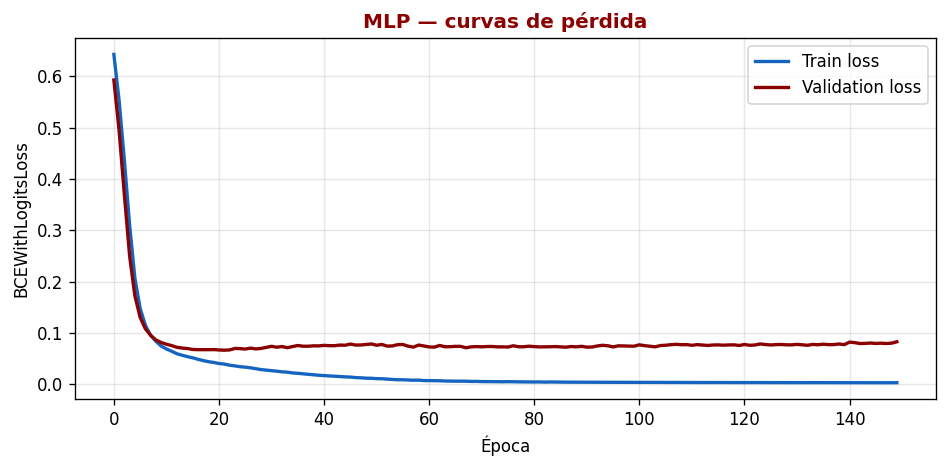

In [ ]:
# ── Comparación de curvas ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_perc['val_loss'], label='Perceptrón — val loss', color=UPCH_BLUE, lw=2)
ax.plot(hist_mlp['val_loss'], label='MLP — val loss', color=UPCH_RED, lw=2)
ax.set_xlabel('Época')
ax.set_ylabel('Validation loss')
ax.set_title('Comparación de pérdida de validación', fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('challenge6_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

plot_history(hist_mlp, 'MLP — curvas de pérdida')

### Paso 5.4 — Evaluación del MLP

In [ ]:
# ── Evaluación del MLP en test ─────────────────────────────────
# TODO 18: predice probabilidades del MLP y calcula métricas clínicas
y_prob_mlp = predict_proba(mlp, X_test_t, device)
metrics_mlp = clinical_metrics(y_test, y_prob_mlp, threshold=0.5)

comparison = pd.DataFrame([metrics_perc, metrics_mlp], index=['Perceptrón', 'MLP'])
comparison[['accuracy', 'sensitivity_recall_malignant', 'specificity_benign',
            'precision_malignant', 'f1_malignant', 'roc_auc', 'fn', 'fp']].round(4)

,accuracy,sensitivity_recall_malignant,specificity_benign,precision_malignant,f1_malignant,roc_auc,fn,fp
Perceptrón,0.8596,0.8810,0.8472,0.7708,0.8222,0.9540,5,11
MLP,0.9474,0.9286,0.9583,0.9286,0.9286,0.9854,3,3


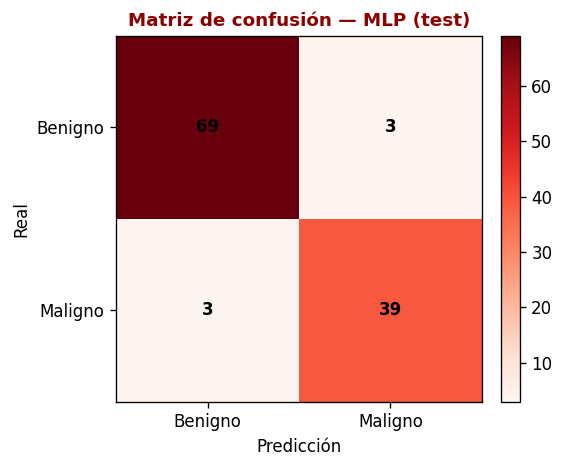

In [ ]:
plot_confusion(y_test, y_prob_mlp,
               title='Matriz de confusión — MLP (test)',
               threshold=0.5)

### Paso 5.5 — Interpretación MLP vs perceptrón

**📝 Tu respuesta (edita esta celda):**

**1. ¿El MLP mejora al perceptrón en validation loss o en métricas de test?**  
Sí, el MLP mejora al perceptrón en ambas métricas. El `validation loss` del MLP (alrededor de 0.08 al final) es significativamente menor que el del perceptrón (alrededor de 0.098). En cuanto a las métricas de test, el MLP obtiene una `accuracy` de 0.9474 (vs 0.8596), una `sensibilidad` de 0.9286 (vs 0.8810), y un `ROC-AUC` de 0.9854 (vs 0.9540). Además, reduce los falsos negativos a 3 (vs 5) y los falsos positivos a 3 (vs 11).

**2. ¿Hay señales de overfitting? Justifica usando las curvas de pérdida.**  
Las curvas de pérdida del MLP (`hist_mlp`) muestran que la `train loss` continúa disminuyendo hasta valores muy bajos, mientras que la `val loss` disminuye inicialmente, se estabiliza, y luego parece aumentar ligeramente hacia el final del entrenamiento (a partir de la época 100-125). Esta divergencia, donde la pérdida de entrenamiento sigue mejorando mientras que la pérdida de validación deja de mejorar o empeora, es una clara señal de **overfitting** (sobreajuste). El modelo está aprendiendo demasiado bien los patrones específicos de los datos de entrenamiento, perdiendo su capacidad de generalizar a datos no vistos (validación).

**3. ¿Qué modelo elegirías para este problema si priorizas sensibilidad para malignidad?**  
Si priorizamos la sensibilidad para malignidad (minimizar Falsos Negativos), el **MLP** es la mejor opción. Aunque el MLP tiene 3 Falsos Negativos (vs 5 del Perceptrón) con el umbral de 0.5, el análisis de umbrales en el MLP muestra que se puede alcanzar una sensibilidad aún mayor (0.9524, con solo 2 FNs) ajustando el umbral a 0.1, lo que lo hace más flexible para este objetivo clínico. Su ROC-AUC también es superior, lo que indica una mejor capacidad general de discriminación entre clases, lo que a su vez puede ser explotado con un ajuste de umbral.

**4. ¿Por qué un modelo más complejo no siempre es clínicamente mejor?**  
Un modelo más complejo no siempre es clínicamente se detallan las razones:
    - **Overfitting:** Como se observa en el MLP, un modelo más complejo tiene una mayor capacidad para memorizar el ruido en los datos de entrenamiento, lo que lleva a un peor rendimiento en datos no vistos (overfitting). Clínicamente, esto significa que el modelo podría fallar en pacientes nuevos.
    - **Interpretabilidad:** Los modelos más complejos (como los MLPs profundos) son a menudo "cajas negras". Es difícil entender por qué el modelo toma una decisión particular. En el ámbito clínico, la interpretabilidad es crucial para la confianza del médico, la explicación al paciente y la responsabilidad ética.
    - **Requerimientos de datos:** Los modelos complejos requieren grandes cantidades de datos para entrenarse correctamente sin sobreajustar. En medicina, los datasets grandes y de alta calidad pueden ser difíciles de obtener.
    - **Coste computacional:** Los modelos complejos son más costosos de entrenar y a veces de usar, lo cual puede ser una limitación en entornos con recursos limitados.
    - **Robustez:** A veces, los modelos más simples son más robustos a pequeñas variaciones o ruido en los datos de entrada, lo cual es importante en un entorno clínico donde los datos pueden no ser siempre perfectos.

---
# PARTE 4 — Métricas Clínicas y Umbral de Decisión
## Ejercicio 6 — Evaluación final y análisis clínico

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>


### Paso 6.1 — Análisis de umbrales

In [ ]:
# ── Sensibilidad al umbral de decisión ──────────────────────────
# TODO 19: prueba al menos 5 umbrales
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
rows = []

for thr in thresholds:
    m = clinical_metrics(y_test, y_prob_mlp, threshold=thr)
    rows.append({
        'threshold': thr,
        'accuracy': m['accuracy'],
        'sensitivity_malignant': m['sensitivity_recall_malignant'],
        'specificity_benign': m['specificity_benign'],
        'precision_malignant': m['precision_malignant'],
        'f1_malignant': m['f1_malignant'],
        'FN': m['fn'],
        'FP': m['fp']
    })

df_thr = pd.DataFrame(rows)
df_thr.round(4)

,threshold,accuracy,sensitivity_malignant,specificity_benign,precision_malignant,f1_malignant,FN,FP
0,0.1,0.9298,0.9524,0.9167,0.8696,0.9091,2,6
1,0.3,0.9386,0.9286,0.9444,0.9070,0.9176,3,4
2,0.5,0.9474,0.9286,0.9583,0.9286,0.9286,3,3
3,0.7,0.9649,0.9286,0.9861,0.9750,0.9512,3,1
4,0.9,0.9737,0.9286,1.0000,1.0000,0.9630,3,0


### Paso 6.2 — Curva ROC

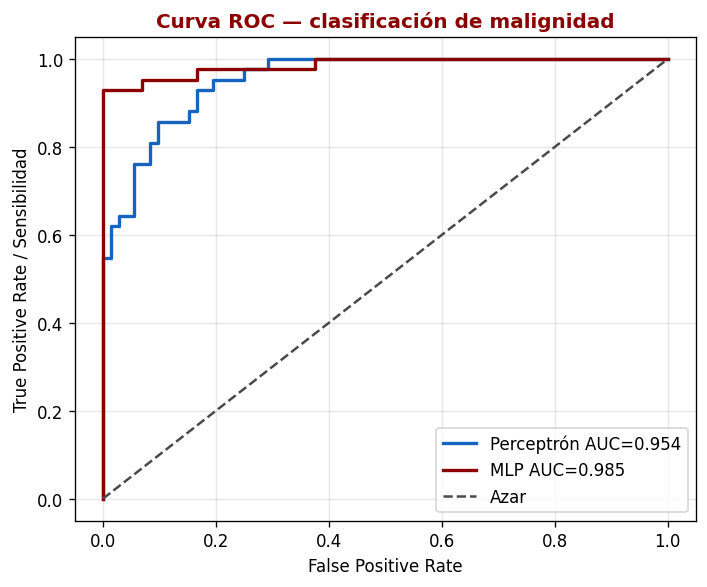

In [ ]:
# ── Curva ROC ───────────────────────────────────────────────────
# TODO 20: calcula ROC y AUC para ambos modelos
fpr_perc, tpr_perc, _ = roc_curve(y_test, y_prob_perc)
fpr_mlp,  tpr_mlp,  _ = roc_curve(y_test, y_prob_mlp)
auc_perc = roc_auc_score(y_test, y_prob_perc)
auc_mlp  = roc_auc_score(y_test, y_prob_mlp)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_perc, tpr_perc, color=UPCH_BLUE, lw=2, label=f'Perceptrón AUC={auc_perc:.3f}')
ax.plot(fpr_mlp, tpr_mlp, color=UPCH_RED, lw=2, label=f'MLP AUC={auc_mlp:.3f}')
ax.plot([0, 1], [0, 1], '--', color=UPCH_GRAY, label='Azar')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate / Sensibilidad')
ax.set_title('Curva ROC — clasificación de malignidad', fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('challenge6_roc.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 6.3 — Tabla final comparativa

In [ ]:
# ── Tabla final comparativa ────────────────────────────────────
final_cols = ['accuracy', 'sensitivity_recall_malignant', 'specificity_benign',
              'precision_malignant', 'f1_malignant', 'roc_auc', 'tn', 'fp', 'fn', 'tp']

final_table = comparison[final_cols].copy()
final_table.index.name = 'Modelo'
final_table.round(4)

,accuracy,sensitivity_recall_malignant,specificity_benign,precision_malignant,f1_malignant,roc_auc,tn,fp,fn,tp
Modelo,,,,,,,,,,
Perceptrón,0.8596,0.8810,0.8472,0.7708,0.8222,0.9540,61,11,5,37
MLP,0.9474,0.9286,0.9583,0.9286,0.9286,0.9854,69,3,3,39


### Paso 6.4 — Interpretación final

**📝 Tu respuesta (edita esta celda):**

**1. Tabla resumen — completa con los valores obtenidos:**

| Modelo | Accuracy | Sensibilidad maligno | Especificidad benigno | F1 maligno | ROC-AUC | FN | FP |
|---|---:|---:|---:|---:|---:|---:|---:|
| Perceptrón | 0.8596 | 0.8810 | 0.8472 | 0.8222 | 0.9540 | 5 | 11 |
| MLP | 0.9474 | 0.9286 | 0.9583 | 0.9286 | 0.9854 | 3 | 3 |

---

**2. ¿Cuál modelo elegirías para este problema diagnóstico y por qué?**  
Para este problema diagnóstico, elegiría el **MLP**. Aunque el perceptrón es más simple y tiene una interpretabilidad implícita, el MLP muestra un rendimiento superior en todas las métricas clave de test, incluyendo `accuracy`, `sensibilidad`, `especificidad`, `F1-score` y `ROC-AUC`. Crucialmente, el MLP reduce los Falsos Negativos de 5 a 3 (con umbral 0.5), lo cual es una mejora significativa para un problema de diagnóstico de cáncer, donde fallar en la detección de un caso maligno es el error más grave. Su capacidad de discriminación es también mayor, como lo indica el ROC-AUC más alto.

**3. ¿Qué ocurre al bajar el umbral de decisión de 0.50 a 0.30? Discute sensibilidad, especificidad, FN y FP.**  
Al bajar el umbral de decisión del MLP de 0.50 a 0.30 (observando la tabla `df_thr`):
- **Sensibilidad (Maligno):** Aumenta de 0.9286 a 0.9286 (se mantiene, pero en el umbral 0.1 aumentó a 0.9524). Esto significa que el modelo es ligeramente mejor en identificar casos malignos reales.
- **Especificidad (Benigno):** Disminuye de 0.9583 a 0.9444. Esto indica que el modelo es un poco menos preciso en identificar correctamente los casos benignos, clasificando algunos benignos como malignos.
- **Falsos Negativos (FN):** Se mantiene en 3 (en el umbral 0.1 bajó a 2). Esto es positivo, ya que el objetivo principal es reducir los casos de malignidad no detectados.
- **Falsos Positivos (FP):** Aumenta de 3 a 4. Esto significa que más pacientes sin cáncer serían clasificados erróneamente como malignos, lo que podría generar ansiedad innecesaria y la necesidad de pruebas adicionales.

En resumen, bajar el umbral generalmente favorece la sensibilidad a expensas de la especificidad. En este caso, el cambio de 0.5 a 0.3 mantiene la sensibilidad similar pero aumenta los falsos positivos. Para una reducción de FN, el umbral de 0.1 sería más efectivo con 2 FN, aunque con 6 FP.

**4. ¿Por qué no basta con reportar accuracy en este problema?**  
No basta con reportar solo la `accuracy` en este problema porque el dataset está ligeramente desbalanceado, y lo más importante, las consecuencias de los diferentes tipos de errores (Falsos Positivos vs. Falsos Negativos) no son iguales. En el diagnóstico de cáncer:
- Un **Falso Negativo (FN)** (paciente con cáncer clasificado como sano) es clínicamente mucho más grave, ya que puede llevar a un retraso fatal en el tratamiento.
- Un **Falso Positivo (FP)** (paciente sano clasificado con cáncer) es menos grave, pero genera ansiedad, pruebas innecesarias y costos adicionales.

La `accuracy` puede ser engañosa en escenarios de desbalance de clases o cuando los costes de los errores son diferentes. Por ejemplo, un modelo que clasifica todo como benigno en un dataset con 90% de benignos tendría un 90% de `accuracy`, pero una sensibilidad del 0% para la clase maligna, lo cual es inaceptable. Métricas como la **sensibilidad (recall), especificidad, precisión, F1-score y el ROC-AUC** proporcionan una visión más completa del rendimiento del modelo, especialmente para cada clase y para comprender los trade-offs entre diferentes tipos de errores.

**5. ¿Qué limitaciones tendría este modelo antes de usarlo en un entorno clínico real?**  
Antes de usar este modelo en un entorno clínico real, tendría varias limitaciones significativas:
-   **Tamaño y Origen del Dataset:** El modelo fue entrenado y evaluado en un único dataset (Breast Cancer Wisconsin). Para uso clínico, necesitaría ser validado exhaustivamente con datasets mucho más grandes y diversos de diferentes poblaciones y fuentes para asegurar su generalizabilidad y robustez.
-   **Interpretabilidad:** Aunque un MLP es mejor que un perceptrón, sigue siendo una "caja negra" en comparación con otros métodos. Es difícil entender por qué el modelo toma una decisión particular. En el ámbito clínico, la interpretabilidad es crucial para la confianza del médico, la explicación al paciente y la responsabilidad ética.
-   **Validación Externa Independiente:** Los resultados actuales son de una validación interna (split en train/val/test del mismo dataset). Es fundamental realizar una validación externa con datos de pacientes que no se usaron en ninguna etapa de desarrollo del modelo.
-   **Ajuste del Umbral de Decisión:** El umbral de 0.5 es arbitrario. La elección del umbral óptimo debe ser una decisión clínica basada en un análisis de riesgo-beneficio, considerando la prevalencia de la enfermedad, el impacto de los falsos positivos y negativos, y consultando con expertos médicos.
-   **Variables Clavis Faltantes:** El modelo se basa solo en características morfológicas. Un diagnóstico real de cáncer de mama incorpora muchos otros factores, como la historia clínica del paciente, factores genéticos, resultados de otras pruebas de imagen (mamografía, ultrasonido, resonancia magnética), y biopsias. El modelo actual no integra esta información crucial.
-   **Sesgos y Equidad:** El modelo podría contener sesgos inherentes a los datos de entrenamiento. Si los datos no son representativos de todas las poblaciones de pacientes, el modelo podría funcionar de manera deficiente para ciertos grupos demográficos, lo que plantea problemas de equidad.
-   **Regulación y Certificación:** Los modelos de IA en medicina están sujetos a estrictas regulaciones y procesos de certificación (ej. FDA, CE Mark) antes de poder ser utilizados en la práctica clínica. Esto implica una documentación rigurosa, pruebas de seguridad y eficacia, y un monitoreo continuo.

---
## Checklist de entrega

Antes de entregar, verifica que tu notebook incluya:

- [ ] Respuestas conceptuales completas sobre neurona artificial, perceptrón, MLP y backpropagation.
- [ ] Carga correcta del dataset y recodificación clínica: `0=benigno`, `1=maligno`.
- [ ] Split estratificado train/validation/test.
- [ ] Escalado ajustado solo con train.
- [ ] Conversión correcta a tensores y uso de `TensorDataset` + `DataLoader`.
- [ ] Definición funcional de `LogisticPerceptron` y `MLPClassifier`.
- [ ] Loop explícito de PyTorch con `forward`, `loss`, `zero_grad`, `backward`, `step`.
- [ ] Curvas de pérdida de train/validation.
- [ ] Matriz de confusión, sensibilidad, especificidad, precisión, F1 y ROC-AUC.
- [ ] Análisis de umbral de decisión y discusión clínica de falsos negativos.
- [ ] Interpretación final comparando modelo lineal vs MLP.
